In [ ]:
! pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.5 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow

In [ ]:
!apt-get install -y vienna-rna


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgsl27 libgslcblas0 libncbi6 ncbi-data readseq
Suggested packages:
  gsl-ref-psdoc | gsl-doc-pdf | gsl-doc-info | gsl-ref-html
The following NEW packages will be installed:
  libgsl27 libgslcblas0 libncbi6 ncbi-data readseq vienna-rna
0 upgraded, 6 newly installed, 0 to remove and 30 not upgraded.
Need to get 11.1 MB of archives.
After this operation, 130 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgslcblas0 amd64 2.7.1+dfsg-3 [94.4 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgsl27 amd64 2.7.1+dfsg-3 [1,000 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libncbi6 amd64 6.1.20170106+dfsg1-9 [3,992 kB]
Get:5 http://archive.ubuntu.com/

In [ ]:
import re
import csv
import os

pam_patterns = {
    "NGG (SpCas9)": r"(?<=.{20})GG",
    "NNGRRT (SaCas9)": r"(?<=.{20})[AG][AG][GA][AT]",
    "NG (Cas9-NG)": r"(?<=.{20})G[ATGC]",
    "TTTV (AsCas12a)": r"TTT[ACG]"
}

# Function to read a FASTA file
def read_fasta(file_path):
    if not os.path.exists(file_path):
        print(f"ERROR: File '{file_path}' not found!")
        return []  # Return empty list if file doesn't exist

    with open(file_path, "r") as f:
        sequences = []
        seq = ""
        for line in f:
            if line.startswith(">"):
                if seq:
                    sequences.append(seq.upper())
                seq = ""
            else:
                seq += line.strip()
        if seq:
            sequences.append(seq.upper())

    if not sequences:
        print("ERROR: No sequences found in the FASTA file!")

    return sequences

# Function to find gRNAs and group by PAM type
def find_grna(seq, pam_patterns):
    grna_dict = {pam: [] for pam in pam_patterns}  # Dictionary to store gRNAs by PAM type
    for pam, pattern in pam_patterns.items():
        for match in re.finditer(pattern, seq, re.IGNORECASE):
            start = match.start()
            if start >= 20:
                grna_seq = seq[start - 20:start]  # Extract 20-nt guide RNA
                grna_dict[pam].append((grna_seq, match.group()))

    return grna_dict

# Process FASTA and save grouped results
def process_fasta(fasta_file, output_csv, pam_patterns):
    print(f"Reading FASTA file from: {fasta_file}")

    sequences = read_fasta(fasta_file)
    if not sequences:
        print("ERROR: No sequences loaded. Exiting.")
        return

    grouped_grnas = {pam: [] for pam in pam_patterns}

    # Extract gRNAs and group them
    for seq in sequences:
        grna_dict = find_grna(seq, pam_patterns)
        for pam in pam_patterns:
            grouped_grnas[pam].extend(grna_dict[pam])

    # Debugging print before writing
    print("Extracted gRNAs:", {pam: len(grnas) for pam, grnas in grouped_grnas.items()})

    # If no gRNAs are found, stop execution
    if all(len(grnas) == 0 for grnas in grouped_grnas.values()):
        print("ERROR: No gRNAs found. Check FASTA sequences and regex.")
        return

    with open(output_csv, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["PAM Type", "gRNA Sequence", "Matched PAM"])
        for pam, grnas in grouped_grnas.items():
            for grna_seq, matched_pam in grnas:
                writer.writerow([pam, grna_seq, matched_pam])

    print(f"✅ gRNA extraction complete! Results saved in '{output_csv}'.")


input_fasta = r"C:\Users\Himabindu\Downloads\sequence (4).txt"
output_csv = r"C:\Users\Himabindu\Desktop\output_grouped_grnas_HBB.csv"

process_fasta(input_fasta, output_csv, pam_patterns)

In [ ]:
import pandas as pd
import subprocess
import numpy as np
from Bio.Seq import Seq
from Bio.SeqUtils import MeltingTemp as mt

# ---------- Feature Functions ----------
def gc_content(sequence):
    return (sequence.count('G') + sequence.count('C')) / len(sequence) * 100 if sequence else 0

def melting_temperature(sequence):
    return mt.Tm_NN(Seq(sequence)) if sequence else np.nan

def calculate_mfe(sequence):
    try:
        result = subprocess.run(["RNAfold"], input=sequence, text=True, capture_output=True, check=True)
        mfe_line = result.stdout.splitlines()[-1]
        mfe_value = float(mfe_line.split()[-1].strip("()"))
        return mfe_value
    except FileNotFoundError:
        print("Warning: RNAfold not found. Install ViennaRNA package.")
        return np.nan
    except Exception as e:
        print(f"RNAfold Error: {e}")
        return np.nan

def self_complementarity(sequence):
    return sum(1 for i in range(len(sequence) - 3) if sequence[i:i+4] in {'ATGC', 'GCAT'})

def at_gc_ratio(sequence):
    at = sequence.count('A') + sequence.count('T')
    gc = sequence.count('G') + sequence.count('C')
    return at / gc if gc else np.nan

# ---------- Load & Process Dataset ----------
input_file = "/content/drive/MyDrive/output_all_cas_pam_combinations_HTT.csv"
df = pd.read_csv(input_file)

# Compute features
df['GC Content (%)'] = df['gRNA Sequence'].apply(gc_content)
df['Melting Temperature (Tm)'] = df['gRNA Sequence'].apply(melting_temperature)
df['Minimum Free Energy (MFE)'] = df['gRNA Sequence'].apply(calculate_mfe)
df['Self-Complementarity Score'] = df['gRNA Sequence'].apply(self_complementarity)
df['AT/GC Ratio'] = df['gRNA Sequence'].apply(at_gc_ratio)

# ---------- Save as Excel ----------
output_excel = "/content/drive/MyDrive/processed_grnas_HTT.xlsx"
df.to_excel(output_excel, index=False)

print(f"✅ Processed Excel saved at: {output_excel}")


✅ Processed Excel saved at: /content/drive/MyDrive/processed_grnas_HTT.xlsx


In [ ]:
import pandas as pd

# File paths (update these with actual file paths)
file_paths = [
    "/content/drive/MyDrive/processed_grnas_HTT.xlsx",
    "/content/drive/MyDrive/processed_grnas_CFTR.xlsx",
    "/content/drive/MyDrive/processed_grnas_HBB.xlsx",
    "/content/drive/MyDrive/processed_grnas_DYSF.xlsx"
]

# Optional: Labels to identify the dataset origin
dataset_labels = ["HTT", "CFTR", "HBB", "DYSF"]

# Read and combine
combined_df = pd.DataFrame()
for path, label in zip(file_paths, dataset_labels):
    df = pd.read_excel(path)
    df["Dataset"] = label  # Add a column to track origin
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Save combined dataframe
combined_output_path = "/content/drive/MyDrive/combined_processed_grnas.xlsx"
combined_df.to_excel(combined_output_path, index=False)

print(f"✅ Combined Excel saved at: {combined_output_path}")


✅ Combined Excel saved at: /content/drive/MyDrive/combined_processed_grnas.xlsx


✅ PCA results saved to: /content/drive/MyDrive/grnas_with_pca_components.xlsx


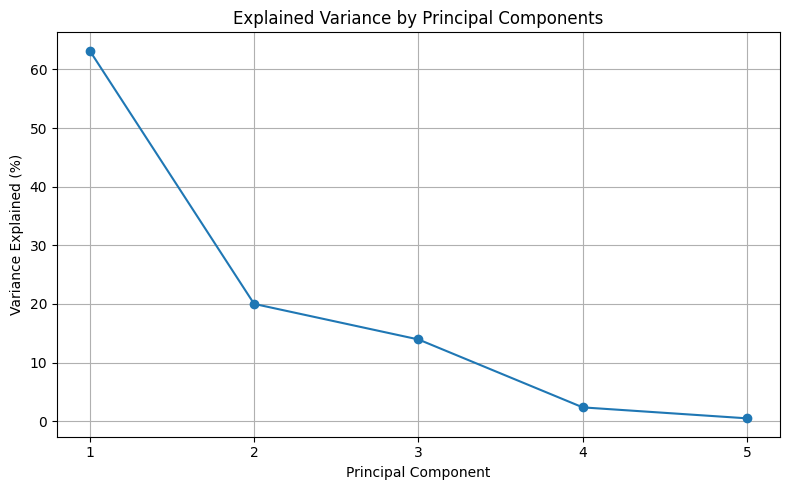

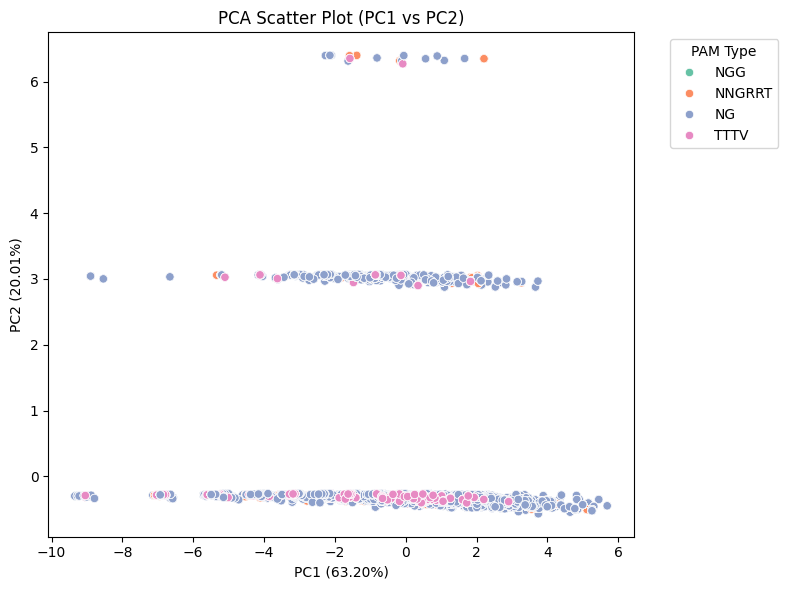

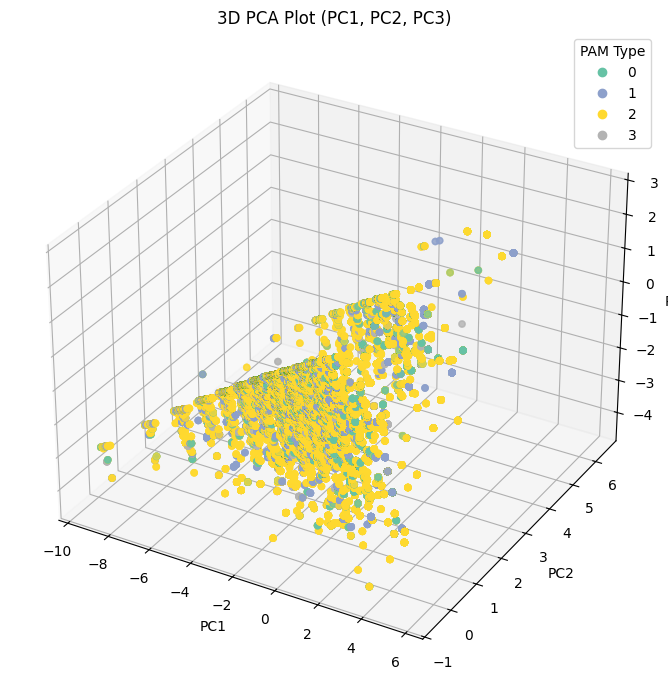

Feature Weights (Normalized):
GC Content (%)                0.223306
Melting Temperature (Tm)      0.236305
Minimum Free Energy (MFE)     0.179917
Self-Complementarity Score    0.136822
AT/GC Ratio                   0.223649
dtype: float64
✅ PCA results with Composite Efficiency Score saved to: /content/drive/MyDrive/grnas_with_pca_components.xlsx


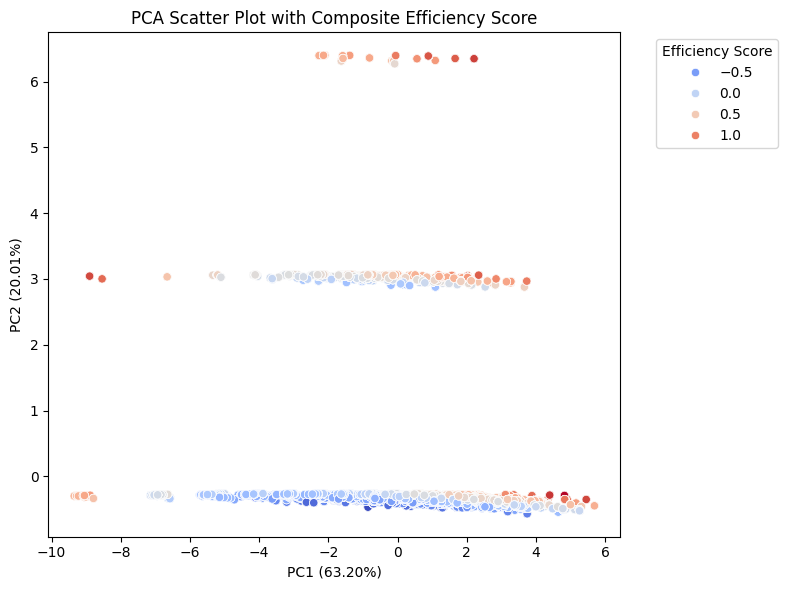

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------- Load Data ----------
file_path = "/content/drive/MyDrive/combined_processed_grnas.xlsx"
df = pd.read_excel(file_path)

# ---------- Select Features for PCA ----------
features = ['GC Content (%)', 'Melting Temperature (Tm)', 'Minimum Free Energy (MFE)',
            'Self-Complementarity Score', 'AT/GC Ratio']
df_clean = df.dropna(subset=features)

# ---------- Normalize Features ----------
scaler = StandardScaler()
normalized_features = scaler.fit_transform(df_clean[features])

# ---------- Apply PCA ----------
pca = PCA(n_components=5)
principal_components = pca.fit_transform(normalized_features)

# ---------- Create PCA DataFrame ----------
pc_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(pca.n_components_)] )
df_pca = pd.concat([df_clean.reset_index(drop=True), pc_df], axis=1)

# ---------- Save Result ----------
output_pca_path = "/content/drive/MyDrive/grnas_with_pca_components.xlsx"
df_pca.to_excel(output_pca_path, index=False)
print(f"✅ PCA results saved to: {output_pca_path}")

# ---------- Scree Plot ----------
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), pca.explained_variance_ratio_ * 100, marker='o')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.grid(True)
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

# ---------- 2D PCA Scatter Plot (PC1 vs PC2) ----------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='PAM Type', palette='Set2')
plt.title('PCA Scatter Plot (PC1 vs PC2)')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.legend(title='PAM Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------- Optional: 3D PCA Scatter Plot ----------
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'],
                     c=pd.factorize(df_pca['PAM Type'])[0], cmap='Set2')
ax.set_title("3D PCA Plot (PC1, PC2, PC3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="PAM Type")
plt.tight_layout()
plt.show()

# ---------- Step 1: Extract PCA Loadings ----------
loadings = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])

# ---------- Step 2: Calculate Feature Weights ----------
# Calculate the sum of absolute loadings for each feature to get its importance
feature_weights = loadings.abs().sum(axis=0)

# Normalize weights to sum to 1 (or 100 for percentage-based weights)
feature_weights_normalized = feature_weights / feature_weights.sum()

# Display normalized feature weights
print("Feature Weights (Normalized):")
print(feature_weights_normalized)

# ---------- Step 3: Compute Composite Efficiency Score ----------
# Calculate the composite average score (weighted sum of normalized features)
composite_score = (normalized_features * feature_weights_normalized.values).sum(axis=1)

# Add the composite score to the PCA DataFrame
df_pca['Composite Efficiency Score'] = composite_score

# ---------- Step 4: Save the Results with Composite Score ----------
df_pca.to_excel(output_pca_path, index=False)
print(f"✅ PCA results with Composite Efficiency Score saved to: {output_pca_path}")

# ---------- Optional: 2D Scatter Plot with Composite Efficiency Score ----------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Composite Efficiency Score', palette='coolwarm')
plt.title('PCA Scatter Plot with Composite Efficiency Score')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.legend(title='Efficiency Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the Excel file
file_path ="/content/drive/MyDrive/combined_processed_grnas.xlsx"
df = pd.read_excel(file_path)

# Select numerical feature columns
features = [
    'GC Content (%)',
    'Melting Temperature (Tm)',
    'Minimum Free Energy (MFE)',
    'Self-Complementarity Score',
    'AT/GC Ratio'
]

# Normalize features using Min-Max scaling
scaler = MinMaxScaler()
normalized = scaler.fit_transform(df[features])

# Create composite efficiency score (mean of normalized features)
df['Efficiency Score'] = pd.DataFrame(normalized, columns=features).mean(axis=1)

# Save the updated DataFrame to a new Excel file
output_file_path = "/content/drive/MyDrive/combined_processed_grnas.xlsx"
df.to_excel(output_file_path, index=False)

print(f"Efficiency scores added and saved to: {output_file_path}")


Efficiency scores added and saved to: /content/drive/MyDrive/combined_processed_grnas.xlsx


In [ ]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# Install PyTorch Geometric and its dependencies (for CUDA 11.7, Colab default)
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu117.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu117.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 34.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.4 MB/s eta 0:00:00


In [ ]:
!pip uninstall torch-scatter torch-sparse torch-cluster torch-spline-conv -y

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-$(python3 -c "import torch; print(torch.__version__)").html


Found existing installation: torch-scatter 2.1.2+pt21cu121
Uninstalling torch-scatter-2.1.2+pt21cu121:
  Successfully uninstalled torch-scatter-2.1.2+pt21cu121
Found existing installation: torch-sparse 0.6.18+pt21cu121
Uninstalling torch-sparse-0.6.18+pt21cu121:
  Successfully uninstalled torch-sparse-0.6.18+pt21cu121
Found existing installation: torch-cluster 1.6.3+pt21cu121
Uninstalling torch-cluster-1.6.3+pt21cu121:
  Successfully uninstalled torch-cluster-1.6.3+pt21cu121
Found existing installation: torch-spline-conv 1.2.2+pt21cu121
Uninstalling torch-spline-conv-1.2.2+pt21cu121:
  Successfully uninstalled torch-spline-conv-1.2.2+pt21cu121
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 75.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 82.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 23.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-$(python3 -c "import torch; print(torch.__version__)").html


Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())


12.4
False


In [ ]:
!pip uninstall torch-scatter torch-sparse torch-cluster torch-spline-conv -y

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
  -f https://data.pyg.org/whl/torch-2.1.0+cpu.html


Found existing installation: torch-scatter 2.1.2+pt21cpu
Uninstalling torch-scatter-2.1.2+pt21cpu:
  Successfully uninstalled torch-scatter-2.1.2+pt21cpu
Found existing installation: torch-sparse 0.6.18+pt21cpu
Uninstalling torch-sparse-0.6.18+pt21cpu:
  Successfully uninstalled torch-sparse-0.6.18+pt21cpu
Found existing installation: torch_cluster 1.6.3
Uninstalling torch_cluster-1.6.3:
  Successfully uninstalled torch_cluster-1.6.3
Found existing installation: torch-spline-conv 1.2.2+pt21cpu
Uninstalling torch-spline-conv-1.2.2+pt21cpu:
  Successfully uninstalled torch-spline-conv-1.2.2+pt21cpu
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cpu.html
  Using cached https://data.pyg.org/whl/torch-2.1.0%2Bcpu/torch_scatter-2.1.2%2Bpt21cpu-cp311-cp311-linux_x86_64.whl (500 kB)
  Using cached https://data.pyg.org/whl/torch-2.1.0%2Bcpu/torch_sparse-0.6.18%2Bpt21cpu-cp311-cp311-linux_x86_64.whl (1.2 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.1/753.1 kB 8.6 MB/s eta 0:00:00

In [ ]:
from torch_geometric.nn import GCNConv
print("GCNConv loaded successfully!")

/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


GCNConv loaded successfully!


In [ ]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cpu.html


Looking in links: https://data.pyg.org/whl/torch-2.1.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.4/500.4 kB 6.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.3/210.3 kB 3.2 MB/s eta 0:00:00


#GCN

In [ ]:
!pip install torch-cluster


In [ ]:
!pip show torch-cluster


Name: torch-cluster
Version: 1.6.3+pt21cpu
Summary: PyTorch Extension Library of Optimized Graph Cluster Algorithms
Home-page: https://github.com/rusty1s/pytorch_cluster
Author: Matthias Fey
Author-email: matthias.fey@tu-dortmund.de
License: 
Location: /usr/local/lib/python3.11/dist-packages
Requires: scipy
Required-by: 


In [ ]:
!pip uninstall torch-geometric -y
!pip uninstall torch-cluster -y

# Reinstall the correct versions
!pip install torch-geometric
!pip install torch-cluster


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-cluster: filename=torch_cluster-1.6.3-cp311-cp311-linux_x86_64.whl size=739064 sha256=dd4b30aadbf6fe2b46a509550254aed020ce069378965156125a76fdb73a3e29
  Stored in directory: /root/.cache/pip/wheels/ef/de/7d/a4211822af99147b93800e9e204f0be21294e3c0b95b3b861a
Successfully built torch-cluster


#GCN


Epoch 1, Loss: 1.4392, Accuracy: 0.2314
Epoch 2, Loss: 1.4920, Accuracy: 0.2542
Epoch 3, Loss: 1.3752, Accuracy: 0.2834
Epoch 4, Loss: 1.3648, Accuracy: 0.2845
Epoch 5, Loss: 1.3653, Accuracy: 0.3221
Epoch 6, Loss: 1.3549, Accuracy: 0.3661
Epoch 7, Loss: 1.3366, Accuracy: 0.3947
Epoch 8, Loss: 1.3160, Accuracy: 0.4133
Epoch 9, Loss: 1.2977, Accuracy: 0.4195
Epoch 10, Loss: 1.2834, Accuracy: 0.4233
Epoch 11, Loss: 1.2657, Accuracy: 0.4350
Epoch 12, Loss: 1.2443, Accuracy: 0.4478
Epoch 13, Loss: 1.2250, Accuracy: 0.4574
Epoch 14, Loss: 1.2066, Accuracy: 0.4690
Epoch 15, Loss: 1.1895, Accuracy: 0.4755
Epoch 16, Loss: 1.1681, Accuracy: 0.4904
Epoch 17, Loss: 1.1458, Accuracy: 0.5024
Epoch 18, Loss: 1.1235, Accuracy: 0.5047
Epoch 19, Loss: 1.1027, Accuracy: 0.5132
Epoch 20, Loss: 1.0788, Accuracy: 0.5308
Epoch 21, Loss: 1.0587, Accuracy: 0.5433
Epoch 22, Loss: 1.0395, Accuracy: 0.5475
Epoch 23, Loss: 1.0179, Accuracy: 0.5586
Epoch 24, Loss: 0.9983, Accuracy: 0.5593
Epoch 25, Loss: 0.9780, A

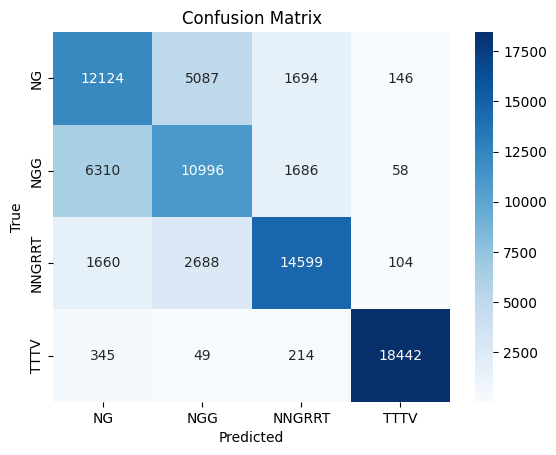

In [ ]:
# 1. Import all libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load and preprocess the data
df = pd.read_excel("/content/drive/MyDrive/combined_processed_grnas.xlsx")
df = df.dropna()

# Encode categorical columns
label_encoders = {}
for col in ['Cas Variant', 'Dataset']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target: PAM Type
pam_le = LabelEncoder()
df['PAM Type'] = pam_le.fit_transform(df['PAM Type'])

# One-hot encode gRNA sequences
def one_hot_encode_seq(seq, max_len=23):
    base_dict = {'A': [1, 0, 0, 0],
                 'T': [0, 1, 0, 0],
                 'G': [0, 0, 1, 0],
                 'C': [0, 0, 0, 1]}
    seq = seq.upper().ljust(max_len, 'N')[:max_len]
    return np.array([base_dict.get(base, [0, 0, 0, 0]) for base in seq]).flatten()

X_seq = np.array([one_hot_encode_seq(seq) for seq in df['gRNA Sequence']])
X_other = df.drop(columns=['gRNA Sequence', 'PAM Type', 'Efficiency Score'])
X_other = X_other.select_dtypes(include=[np.number])

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_other)

# Combine all features
X = np.hstack((X_seq, X_scaled))
y = df['PAM Type'].values

# 3. Balance dataset using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 5. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 6. Define GCN model
class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = self.fc(x)
        return x

# 7. Manual k-NN graph construction using sklearn
def knn_graph_custom(X, k=10):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, indices = nbrs.kneighbors(X)

    row = []
    col = []
    for i in range(len(indices)):
        row.extend([i] * k)
        col.extend(indices[i])

    edge_index = torch.tensor([row, col], dtype=torch.long)
    return edge_index

# Generate edge_index for train and test data
edge_index_train = knn_graph_custom(X_train_tensor.numpy(), k=10)
edge_index_test = knn_graph_custom(X_test_tensor.numpy(), k=10)

# PyG data for train and test
train_data = Data(x=X_train_tensor, edge_index=edge_index_train, y=y_train_tensor)
test_data = Data(x=X_test_tensor, edge_index=edge_index_test, y=y_test_tensor)

# Model setup
input_dim = X_train_tensor.shape[1]
hidden_dim = 64
output_dim = len(np.unique(y))
model = GCN(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(train_data)
    loss = criterion(out, train_data.y)
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    acc = accuracy_score(train_data.y.numpy(), pred.detach().numpy())
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    out = model(test_data)
    pred = out.argmax(dim=1)
    acc = accuracy_score(test_data.y.numpy(), pred.numpy())
    print("Test Accuracy:", acc)
    print(classification_report(test_data.y.numpy(), pred.numpy()))

    # Confusion Matrix
    cm = confusion_matrix(test_data.y.numpy(), pred.numpy())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pam_le.classes_, yticklabels=pam_le.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.4 MB/s eta 0:00:00


In [ ]:
import gradio as gr

def predict_pam_type(seq):
    # Validate sequence length
    if len(seq) != 20 or any(base not in "ATGC" for base in seq.upper()):
        return "Invalid gRNA sequence. Must be 20 characters and only A/T/G/C."

    # Preprocess input
    encoded = one_hot_encode_seq(seq)  # Same function used in training
    features = np.hstack((encoded, np.zeros(input_dim - len(encoded))))  # padding if needed
    input_tensor = torch.tensor(features, dtype=torch.float).unsqueeze(0)

    # Inference
    model.eval()
    with torch.no_grad():
        dummy_edge_index = torch.tensor([[0], [0]], dtype=torch.long)  # self-loop
        data = Data(x=input_tensor, edge_index=dummy_edge_index)
        out = model(data)
        pred = out.argmax(dim=1).item()

    return pam_le.inverse_transform([pred])[0]  # convert back to label

ui = gr.Interface(
    fn=predict_pam_type,
    inputs=gr.Textbox(label="Enter 20-base gRNA Sequence (A/T/G/C only)"),
    outputs=gr.Textbox(label="Predicted PAM Type"),
    title="PAM Type Predictor",
    description="Input a 20-length gRNA sequence to predict its PAM Type using GCN model."
)

ui.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dc9acb5892a71f7200.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install -U transformers --quiet


In [ ]:

# 2. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
from torch.utils.data import Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Load and preprocess the DataFrame
df = pd.read_excel("/content/drive/MyDrive/combined_processed_grnas.xlsx")
df = df.dropna()

# Encode target: PAM Type
pam_le = LabelEncoder()
df['PAM Type'] = pam_le.fit_transform(df['PAM Type'])

# Extract sequences and labels
texts = df['gRNA Sequence'].values
labels = df['PAM Type'].values

# 4. Train-test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

# 5. Tokenize gRNA sequences using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class GRNADataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=32)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = GRNADataset(train_texts, train_labels, tokenizer)
test_dataset = GRNADataset(test_texts, test_labels, tokenizer)

# 6. Load pretrained BERT model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(np.unique(labels)))

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
)

# 8. Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# 9. Train the model
trainer.train()

# 10. Evaluate the model
preds = trainer.predict(test_dataset)
pred_labels = np.argmax(preds.predictions, axis=1)

# Accuracy and classification metrics
print("Test Accuracy:", accuracy_score(test_labels, pred_labels))
print(classification_report(test_labels, pred_labels, target_names=pam_le.classes_))

# 11. Confusion Matrix
cm = confusion_matrix(test_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pam_le.classes_, yticklabels=pam_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

# RNN

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight

# 1. Load and preprocess the data
df = pd.read_excel("/content/drive/MyDrive/combined_processed_grnas.xlsx")
df = df.dropna()

# Encode categorical columns
label_encoders = {}
for col in ['Cas Variant', 'Dataset']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target: PAM Type
pam_le = LabelEncoder()
df['PAM Type'] = pam_le.fit_transform(df['PAM Type'])

# One-hot encode gRNA sequences
def one_hot_encode_seq(seq, max_len=23):
    base_dict = {'A': [1, 0, 0, 0],
                 'T': [0, 1, 0, 0],
                 'G': [0, 0, 1, 0],
                 'C': [0, 0, 0, 1]}
    seq = seq.upper().ljust(max_len, 'N')[:max_len]
    return np.array([base_dict.get(base, [0, 0, 0, 0]) for base in seq]).flatten()

X_seq = np.array([one_hot_encode_seq(seq) for seq in df['gRNA Sequence']])
X_other = df.drop(columns=['gRNA Sequence', 'PAM Type', 'Efficiency Score'])
X_other = X_other.select_dtypes(include=[np.number])

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_other)

# Combine all features
X = np.hstack((X_seq, X_scaled))
y = df['PAM Type'].values

# 2. SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 5. Define RNN model
class RNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RNN, self).__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add time-step dimension
        out, (hn, cn) = self.rnn(x)
        x = self.fc(hn[-1])
        return x

# 6. Training function
def train_model(model, criterion, optimizer, X_train, y_train, epochs=30, batch_size=64):
    model.train()
    dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        for xb, yb in dataloader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            out = model(X_train)
            pred = out.argmax(dim=1)
            acc = accuracy_score(y_train.numpy(), pred.numpy())
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")

# 7. Evaluation function
def evaluate_model(model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        out = model(X_test_tensor)
        pred = out.argmax(dim=1)
        acc = accuracy_score(y_test_tensor.numpy(), pred.numpy())
        print("\nTest Accuracy:", acc)
        print("Classification Report:\n", classification_report(y_test_tensor.numpy(), pred.numpy()))
        print("Confusion Matrix:\n", confusion_matrix(y_test_tensor.numpy(), pred.numpy()))

# 8. Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# 9. Train and evaluate RNN
input_dim = X_train_tensor.shape[1]
hidden_dim = 64
output_dim = len(np.unique(y))

rnn_model = RNN(input_dim, hidden_dim, output_dim)
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
rnn_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("\nTraining RNN...")
train_model(rnn_model, rnn_criterion, rnn_optimizer, X_train_tensor, y_train_tensor)
evaluate_model(rnn_model, X_test_tensor, y_test_tensor)


Training RNN...
Epoch 1, Loss: 0.3886, Accuracy: 0.7990
Epoch 2, Loss: 0.4641, Accuracy: 0.8372
Epoch 3, Loss: 0.3059, Accuracy: 0.8459
Epoch 4, Loss: 0.3391, Accuracy: 0.8509
Epoch 5, Loss: 0.4043, Accuracy: 0.8557
Epoch 6, Loss: 0.3207, Accuracy: 0.8546
Epoch 7, Loss: 0.2022, Accuracy: 0.8547
Epoch 8, Loss: 0.4837, Accuracy: 0.8561
Epoch 9, Loss: 0.2536, Accuracy: 0.8582
Epoch 10, Loss: 0.2433, Accuracy: 0.8586
Epoch 11, Loss: 0.3378, Accuracy: 0.8590
Epoch 12, Loss: 0.2911, Accuracy: 0.8602
Epoch 13, Loss: 0.4902, Accuracy: 0.8610
Epoch 14, Loss: 0.4067, Accuracy: 0.8593
Epoch 15, Loss: 0.4250, Accuracy: 0.8582
Epoch 16, Loss: 0.4172, Accuracy: 0.8603
Epoch 17, Loss: 0.1494, Accuracy: 0.8580
Epoch 18, Loss: 0.3523, Accuracy: 0.8616
Epoch 19, Loss: 0.3377, Accuracy: 0.8596
Epoch 20, Loss: 0.4187, Accuracy: 0.8598
Epoch 21, Loss: 0.2990, Accuracy: 0.8596
Epoch 22, Loss: 0.2586, Accuracy: 0.8610
Epoch 23, Loss: 0.4165, Accuracy: 0.8597
Epoch 24, Loss: 0.3451, Accuracy: 0.8615
Epoch 25

# CNN

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight

# 1. Load and preprocess the data
df = pd.read_excel("/content/drive/MyDrive/combined_processed_grnas.xlsx")
df = df.dropna()

# Encode categorical columns
label_encoders = {}
for col in ['Cas Variant', 'Dataset']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target: PAM Type
pam_le = LabelEncoder()
df['PAM Type'] = pam_le.fit_transform(df['PAM Type'])

# One-hot encode gRNA sequences
def one_hot_encode_seq(seq, max_len=23):
    base_dict = {'A': [1, 0, 0, 0],
                 'T': [0, 1, 0, 0],
                 'G': [0, 0, 1, 0],
                 'C': [0, 0, 0, 1]}
    seq = seq.upper().ljust(max_len, 'N')[:max_len]
    return np.array([base_dict.get(base, [0, 0, 0, 0]) for base in seq])

X_seq = np.array([one_hot_encode_seq(seq) for seq in df['gRNA Sequence']])  # shape: (N, 23, 4)
X_other = df.drop(columns=['gRNA Sequence', 'PAM Type', 'Efficiency Score'])
X_other = X_other.select_dtypes(include=[np.number])

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_other)

# Combine all features: flatten seq + concat with numeric
X_flattened_seq = X_seq.reshape(X_seq.shape[0], -1)
X = np.hstack((X_flattened_seq, X_scaled))
y = df['PAM Type'].values

# 2. SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 4. Convert to PyTorch tensors and reshape for CNN
X_train_tensor = torch.tensor(X_train, dtype=torch.float).view(-1, 1, X_train.shape[1])
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float).view(-1, 1, X_test.shape[1])
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 5. Define CNN model
class CNN(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.fc1 = nn.Linear((input_length // 2) * 64, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))  # shape: (batch, 32, L)
        x = self.pool(x)           # shape: (batch, 32, L//2)
        x = F.relu(self.conv2(x))  # shape: (batch, 64, L//2)
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 6. Training function
def train_model(model, criterion, optimizer, X_train, y_train, epochs=20, batch_size=64):
    model.train()
    dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        for xb, yb in dataloader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            out = model(X_train)
            pred = out.argmax(dim=1)
            acc = accuracy_score(y_train.numpy(), pred.numpy())
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")

# 7. Evaluation function
def evaluate_model(model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        out = model(X_test_tensor)
        pred = out.argmax(dim=1)
        acc = accuracy_score(y_test_tensor.numpy(), pred.numpy())
        print("\nTest Accuracy:", acc)
        print("Classification Report:\n", classification_report(y_test_tensor.numpy(), pred.numpy()))
        print("Confusion Matrix:\n", confusion_matrix(y_test_tensor.numpy(), pred.numpy()))

# 8. Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# 9. Train and evaluate CNN
input_length = X_train.shape[1]
num_classes = len(np.unique(y_train))

cnn_model = CNN(input_length, num_classes)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("\nTraining CNN...")
train_model(cnn_model, cnn_criterion, cnn_optimizer, X_train_tensor, y_train_tensor)
evaluate_model(cnn_model, X_test_tensor, y_test_tensor)
torch.save(cnn_model.state_dict(), "/content/drive/MyDrive/cnn_model.pt")


Training CNN...
Epoch 1, Loss: 0.3959, Accuracy: 0.8383
Epoch 2, Loss: 0.4319, Accuracy: 0.8470
Epoch 3, Loss: 0.1237, Accuracy: 0.8561
Epoch 4, Loss: 0.3831, Accuracy: 0.8564
Epoch 5, Loss: 0.3047, Accuracy: 0.8611
Epoch 6, Loss: 0.3003, Accuracy: 0.8591
Epoch 7, Loss: 0.3058, Accuracy: 0.8611
Epoch 8, Loss: 0.2011, Accuracy: 0.8613
Epoch 9, Loss: 0.5330, Accuracy: 0.8627
Epoch 10, Loss: 0.3394, Accuracy: 0.8639
Epoch 11, Loss: 0.2556, Accuracy: 0.8643
Epoch 12, Loss: 0.2131, Accuracy: 0.8641
Epoch 13, Loss: 0.2742, Accuracy: 0.8642
Epoch 14, Loss: 0.3823, Accuracy: 0.8642
Epoch 15, Loss: 0.2045, Accuracy: 0.8638
Epoch 16, Loss: 0.2072, Accuracy: 0.8647
Epoch 17, Loss: 0.2484, Accuracy: 0.8643
Epoch 18, Loss: 0.3353, Accuracy: 0.8650
Epoch 19, Loss: 0.2965, Accuracy: 0.8642
Epoch 20, Loss: 0.4537, Accuracy: 0.8633

Test Accuracy: 0.8627463846093278
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.65      0.78     19051
    

In [ ]:
import joblib
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")
joblib.dump(pam_le, "/content/drive/MyDrive/pam_encoder.pkl")

['/content/drive/MyDrive/pam_encoder.pkl']

In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Replace this list with your actual Cas variant values used during training
cas_variants = ["AsCas12a", "Cas9-NG", "SaCas9","SpCas9"]  # example

# Fit LabelEncoder
cas_le = LabelEncoder()
cas_le.fit(cas_variants)

# Save to file
joblib.dump(cas_le, "/content/drive/MyDrive/cas_encoder.pkl")
print("cas_encoder.pkl saved successfully!")


cas_encoder.pkl saved successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ---------- 1. Define the CNN model class ----------
class CNN(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.fc1 = nn.Linear((input_length // 2) * 64, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ---------- 2. One-hot encoding ----------
def one_hot_encode_seq(seq, max_len=23):
    base_dict = {'A': [1, 0, 0, 0],
                 'T': [0, 1, 0, 0],
                 'G': [0, 0, 1, 0],
                 'C': [0, 0, 0, 1]}
    seq = seq.upper().ljust(max_len, 'N')[:max_len]
    return np.array([base_dict.get(base, [0, 0, 0, 0]) for base in seq])

# ---------- 3. Load encoders and scaler ----------
scaler_path = "/content/drive/MyDrive/scaler.pkl"
pam_encoder_path = "/content/drive/MyDrive/pam_encoder.pkl"
cas_encoder_path = "/content/drive/MyDrive/cas_encoder.pkl"

scaler = joblib.load(scaler_path)
pam_le = joblib.load(pam_encoder_path)
cas_le = joblib.load(cas_encoder_path)

# ---------- 4. User Inputs ----------
user_seq = input("Enter a gRNA sequence (20 bases): ")
cas_variant_input = input("Enter the Cas variant (e.g., SpCas9): ")

# Encode sequence
encoded_seq = one_hot_encode_seq(user_seq)  # shape: (23, 4)
flattened_seq = encoded_seq.flatten().reshape(1, -1)

# Encode Cas variant
cas_variant_encoded = cas_le.transform([cas_variant_input]).reshape(1, -1)  # shape: (1, 1)

# ---------- 5. Dummy numeric features ----------
# Update to include Cas variant
dummy_features = np.array([[0, 0, 0, 0, 0, 0]])  # assuming 6 other features
combined_features = np.hstack((dummy_features, cas_variant_encoded))  # now 7 total

# Scale numeric features
scaled_features = scaler.transform(combined_features)

# ---------- 6. Combine sequence and features ----------
final_input = np.hstack((flattened_seq, scaled_features))  # shape: (1, total_features)

# ---------- 7. Prepare for model ----------
input_tensor = torch.tensor(final_input, dtype=torch.float).view(-1, 1, final_input.shape[1])
input_length = final_input.shape[1]
num_classes = len(pam_le.classes_)

# ---------- 8. Load and Run Model ----------
model = CNN(input_length=input_length, num_classes=num_classes)
model.load_state_dict(torch.load("/content/drive/MyDrive/cnn_model.pt", map_location=torch.device('cpu')))
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    pred_idx = output.argmax(dim=1).item()
    pred_label = pam_le.inverse_transform([pred_idx])[0]

print(f"\nPredicted PAM Type: {pred_label}")


Enter a gRNA sequence (20 bases): ACCCTGGAAAAGCTGATGAA
Enter the Cas variant (e.g., SpCas9): SpCas9

Predicted PAM Type: NG


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight

# 1. Load and preprocess the data
df = pd.read_excel("/content/drive/MyDrive/combined_processed_grnas.xlsx")
df = df.dropna()

# Encode categorical columns
label_encoders = {}
for col in ['Cas Variant', 'Dataset']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target: PAM Type
pam_le = LabelEncoder()
df['PAM Type'] = pam_le.fit_transform(df['PAM Type'])

# One-hot encode gRNA sequences
def one_hot_encode_seq(seq, max_len=23):
    base_dict = {'A': [1, 0, 0, 0],
                 'T': [0, 1, 0, 0],
                 'G': [0, 0, 1, 0],
                 'C': [0, 0, 0, 1]}
    seq = seq.upper().ljust(max_len, 'N')[:max_len]
    return np.array([base_dict.get(base, [0, 0, 0, 0]) for base in seq]).flatten()

X_seq = np.array([one_hot_encode_seq(seq) for seq in df['gRNA Sequence']])
X_other = df.drop(columns=['gRNA Sequence', 'PAM Type', 'Efficiency Score'])
X_other = X_other.select_dtypes(include=[np.number])

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_other)

# Combine all features
X = np.hstack((X_seq, X_scaled))
y = df['PAM Type'].values

# 2. SMOTE for class balancing
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 5. Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

# 6. Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.dropout(x, p=0.1, training=self.training)
        x = F.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

# 7. Train the MLP model
def train_model(model, criterion, optimizer, X_train, y_train, epochs=30, batch_size=64):
    model.train()
    dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        for xb, yb in dataloader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            out = model(X_train)
            pred = out.argmax(dim=1)
            acc = accuracy_score(y_train.numpy(), pred.numpy())
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")

# 8. Evaluate the model
def evaluate_model(model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        out = model(X_test_tensor)
        pred = out.argmax(dim=1)
        acc = accuracy_score(y_test_tensor.numpy(), pred.numpy())
        print(f"\nTest Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(y_test_tensor.numpy(), pred.numpy()))
        print("Confusion Matrix:")
        print(confusion_matrix(y_test_tensor.numpy(), pred.numpy()))

# 9. Run training and evaluation
input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = len(np.unique(y))

mlp_model = MLP(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("\nTraining MLP...")
train_model(mlp_model, criterion, optimizer, X_train_tensor, y_train_tensor)
evaluate_model(mlp_model, X_test_tensor, y_test_tensor)



Training MLP...
Epoch 1, Loss: 0.6445, Accuracy: 0.7760
Epoch 2, Loss: 0.4641, Accuracy: 0.7970
Epoch 3, Loss: 0.3766, Accuracy: 0.8042
Epoch 4, Loss: 0.5040, Accuracy: 0.8115
Epoch 5, Loss: 0.4083, Accuracy: 0.8143
Epoch 6, Loss: 0.3489, Accuracy: 0.8177
Epoch 7, Loss: 0.4937, Accuracy: 0.8189
Epoch 8, Loss: 0.6876, Accuracy: 0.8225
Epoch 9, Loss: 0.5124, Accuracy: 0.8201
Epoch 10, Loss: 0.4000, Accuracy: 0.8245
Epoch 11, Loss: 0.3485, Accuracy: 0.8262
Epoch 12, Loss: 0.4487, Accuracy: 0.8249
Epoch 13, Loss: 0.5761, Accuracy: 0.8275
Epoch 14, Loss: 0.6172, Accuracy: 0.8273
Epoch 15, Loss: 0.3532, Accuracy: 0.8245
Epoch 16, Loss: 0.4977, Accuracy: 0.8297
Epoch 17, Loss: 0.4525, Accuracy: 0.8270
Epoch 18, Loss: 0.5585, Accuracy: 0.8235
Epoch 19, Loss: 0.2248, Accuracy: 0.8308
Epoch 20, Loss: 0.5250, Accuracy: 0.8295
Epoch 21, Loss: 0.6056, Accuracy: 0.8321
Epoch 22, Loss: 0.6161, Accuracy: 0.8314
Epoch 23, Loss: 0.3238, Accuracy: 0.8306
Epoch 24, Loss: 0.4464, Accuracy: 0.8311
Epoch 25

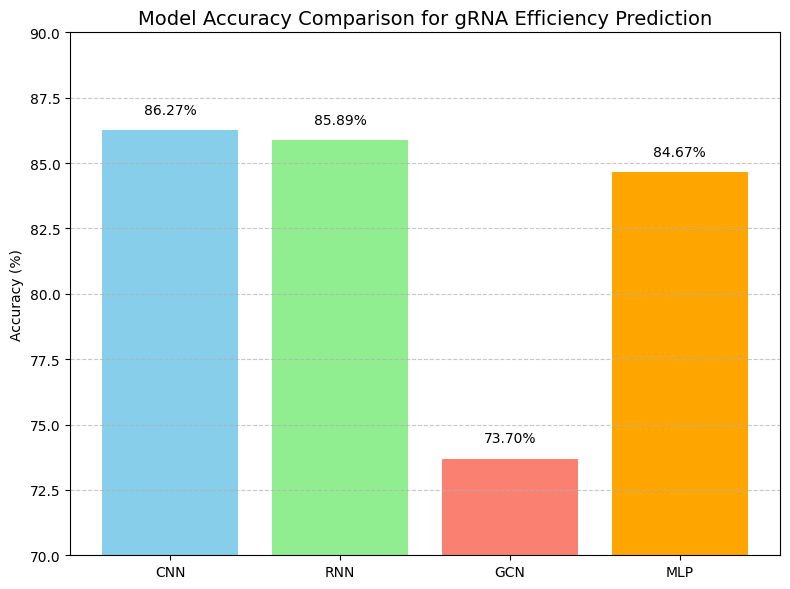

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = ['CNN', 'RNN', 'GCN', 'MLP']

# Accuracies in percentage (replace with actual values if different)
accuracies = [86.27, 85.89, 73.70, 84.67]

# Colors for better distinction
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=colors)

# Annotate each bar with accuracy
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f'{height:.2f}%', ha='center', va='bottom')

# Plot settings
plt.title('Model Accuracy Comparison for gRNA Efficiency Prediction', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(70, 90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import numpy as np

# Load the Excel file
df = pd.read_excel("/content/drive/MyDrive/combined_processed_grnas.xlsx")  # replace with actual filename

# Display the first few rows
print("Sample data:\n", df.head())

# Extract gRNA sequences (assuming the column name is 'sequence')
sequences = df['gRNA Sequence'].astype(str).str.upper()

# One-hot encode sequences into shape (samples, 23, 4)
def one_hot_encode(seq):
    mapping = {'A': [1, 0, 0, 0],
               'C': [0, 1, 0, 0],
               'G': [0, 0, 1, 0],
               'T': [0, 0, 0, 1]}
    return np.array([mapping[base] for base in seq])

encoded_seqs = np.array([one_hot_encode(seq) for seq in sequences])

print("Shape of encoded sequences:", encoded_seqs.shape)  # Should be (N, 23, 4)

# Save this input to .npy if you want to use it in SHAP or model prediction
np.save("shap_input.npy", encoded_seqs)

Sample data:
   Cas Variant PAM Type         gRNA Sequence Matched PAM  GC Content (%)  \
0      SpCas9      NGG  ACCCTGGAAAAGCTGATGAA          GG            45.0   
1      SaCas9      NGG  ACCCTGGAAAAGCTGATGAA          GG            45.0   
2     Cas9-NG      NGG  ACCCTGGAAAAGCTGATGAA          GG            45.0   
3    AsCas12a      NGG  ACCCTGGAAAAGCTGATGAA          GG            45.0   
4      SpCas9      NGG  CTTCCTCAGCCGCCGCCGCA          GG            75.0   

   Melting Temperature (Tm)  Minimum Free Energy (MFE)  \
0                 51.095051                        0.0   
1                 51.095051                        0.0   
2                 51.095051                        0.0   
3                 51.095051                        0.0   
4                 64.469331                       -0.4   

   Self-Complementarity Score  AT/GC Ratio Dataset  Efficiency Score  
0                           0     1.222222     HTT          0.392729  
1                           0     1.22

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_excel("/content/drive/MyDrive/combined_processed_grnas.xlsx").dropna()

# Encode categorical columns
for col in ['Cas Variant', 'Dataset']:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode target
pam_le = LabelEncoder()
df['PAM Type'] = pam_le.fit_transform(df['PAM Type'])

# One-hot encode gRNA
def one_hot_encode_seq(seq, max_len=23):
    base_dict = {'A': [1, 0, 0, 0],
                 'T': [0, 1, 0, 0],
                 'G': [0, 0, 1, 0],
                 'C': [0, 0, 0, 1]}
    seq = seq.upper().ljust(max_len, 'N')[:max_len]
    return np.array([base_dict.get(base, [0, 0, 0, 0]) for base in seq])

X_seq = np.array([one_hot_encode_seq(seq) for seq in df['gRNA Sequence']])
X_other = df.drop(columns=['gRNA Sequence', 'PAM Type', 'Efficiency Score'])
X_other = X_other.select_dtypes(include=[np.number])

# Scale numeric features and combine
X_scaled = StandardScaler().fit_transform(X_other)
X_flattened_seq = X_seq.reshape(X_seq.shape[0], -1)
X = np.hstack((X_flattened_seq, X_scaled))
y = df['PAM Type'].values

# Apply SMOTE and split
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)


In [ ]:
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# 1. Redefine the model architecture (same as before)
class CNN(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.fc1 = nn.Linear((input_length // 2) * 64, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 2. Load the saved model weights
input_length = X_train.shape[1]
num_classes = len(np.unique(y_train))

model = CNN(input_length=input_length, num_classes=num_classes)
model.load_state_dict(torch.load('/content/drive/MyDrive/cnn_model.pt'))
model.eval()

# 3. Prepare background data and input sample (must have shape [batch_size, 1, input_length])
background = torch.tensor(X_train[:100], dtype=torch.float32).view(-1, 1, input_length)
sample_input = torch.tensor(X_train[100:110], dtype=torch.float32).view(-1, 1, input_length)

# 4. Use SHAP DeepExplainer
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(sample_input)

# 5. Calculate feature importance by computing the mean absolute SHAP value for each feature
# Combine SHAP values for all classes
shap_values_combined = np.abs(shap_values[0])  # For multi-class, you can take the absolute value of the first class

# Calculate the mean absolute SHAP value across all samples for each feature
feature_importance = np.mean(shap_values_combined, axis=0)

# 6. Print the feature importance values
for i, importance in enumerate(feature_importance):
    print(f"Feature {i} importance: {importance}")


Feature 0 importance: [0.01521731 0.32555031 0.29752523 0.13839716]
Feature 1 importance: [0.15574974 0.10959376 0.06018104 0.06346472]
Feature 2 importance: [0.08213899 0.05892618 0.12590092 0.29994229]
Feature 3 importance: [0.37380377 0.26691829 0.16687478 0.269135  ]
Feature 4 importance: [0.3972721  0.50374708 1.07736978 0.11039889]
Feature 5 importance: [0.08771917 0.40646027 0.44371705 0.35746004]
Feature 6 importance: [0.12832862 0.39070748 0.05935235 0.63013776]
Feature 7 importance: [0.24236982 0.27754341 0.45164421 0.22320996]
Feature 8 importance: [0.04714492 0.20986783 0.04270621 0.44127586]
Feature 9 importance: [0.27587488 0.49478434 0.24504609 0.52152599]
Feature 10 importance: [1.18411079 1.29835603 0.38632095 2.97454071]
Feature 11 importance: [0.10816127 0.15033141 0.36344021 0.10929339]
Feature 12 importance: [0.12373828 0.05950842 0.17537793 0.61874977]
Feature 13 importance: [0.81367539 0.94757088 0.32779112 2.45201139]
Feature 14 importance: [0.00946124 0.2663306